## Practice Lab 20: Convolutional Neural Networks
In this lab we will look at how Convolutional Neural Networks for classification and regression. \
Based on Chapter 14 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice20_CNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [26]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# Add for GPU BEFORE JSON
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
####################################

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

Added two functions for plotting

In [27]:
def plot_image(image):
    plt.imshow(image, cmap="gray", interpolation="nearest")
    plt.axis("off")

def plot_color_image(image):
    plt.imshow(image, interpolation="nearest")
    plt.axis("off")

### Exercise 1
Load the two images below and apply the vertical and horizontal filters.\
Check all dimensions. The plot one row of one of the figures before and after convolutions. \
Show how the convolution with the horizontal filter produces a smoothing along the rows.

In [3]:
import numpy as np
from sklearn.datasets import load_sample_image
# Load sample images
china = load_sample_image("china.jpg") / 255
flower = load_sample_image("flower.jpg") / 255
images = np.array([china, flower])
batch_size, height, width, channels = images.shape
# Create 2 filters
filters = np.zeros(shape=(7, 7, channels, 2), dtype=np.float32)
filters[:, 3, :, 0] = 1  # vertical line
filters[3, :, :, 1] = 1  # horizontal line

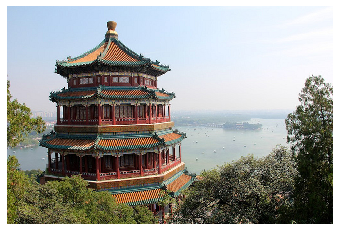

In [4]:
plot_image(china)

In [5]:
print(china.shape)

(427, 640, 3)


In [6]:
print(flower.shape)

(427, 640, 3)


Text(0.5, 1.0, 'column')

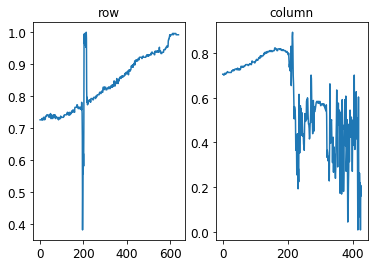

In [7]:
# show a row and a column of the original picture
plt.subplot(121);plt.plot(china[50,:,0]);plt.title('row')
plt.subplot(122);plt.plot(china[:,50,0]);plt.title('column')

In [8]:
print(images.shape)

(2, 427, 640, 3)


In [9]:
print(filters.shape)

(7, 7, 3, 2)


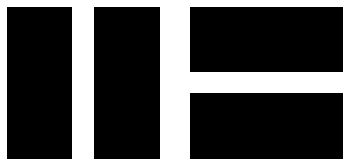

In [10]:
plt.subplot(121);plot_image(filters[:,:,:,0])
plt.subplot(122);plot_image(filters[:,:,:,1])

In [11]:
outputs = tf.nn.conv2d(images, filters, strides=1, padding="SAME")

In [12]:
print(outputs.shape)

(2, 427, 640, 2)


In [13]:
print(images.shape)

(2, 427, 640, 3)


In [14]:
print(filters.shape)

(7, 7, 3, 2)


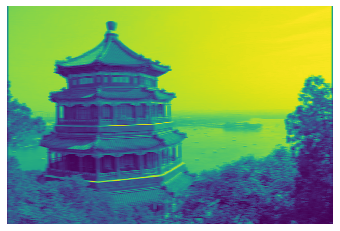

In [15]:
plot_color_image(outputs[0,:,:,1])

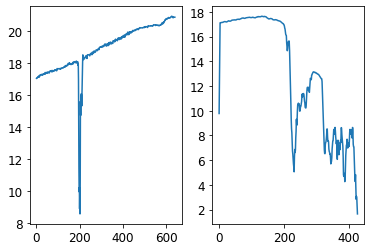

In [16]:
# plot a row and a column after the vertical filter
plt.subplot(121);plt.plot(outputs[0,50,:,0])
plt.subplot(122);plt.plot(outputs[0,:,50,0])

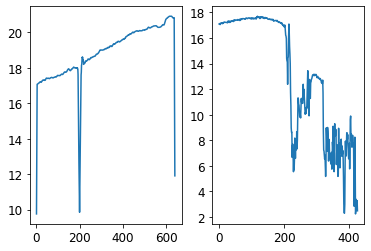

In [17]:
# plot a row and a column after the horizontal filter
plt.subplot(121);plt.plot(outputs[0,50,:,1])
plt.subplot(122);plt.plot(outputs[0,:,50,1])

### Exercise 2
Write conv2d for the mnist data set and compare with the 1D neural network we did in a previous lab.\
To treat each digit as an image, you need to add the feature axis, 1 in this case because it is black-white image.

In [18]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [19]:
print(X_train.shape)

(55000, 28, 28, 1)


In [20]:
print(X_valid.shape)
print(X_test.shape)

(5000, 28, 28, 1)
(10000, 28, 28, 1)


In [21]:
#create a default layer to avoid repeating
from functools import partial
DefaultConv2D = partial(keras.layers.Conv2D, kernel_size=(3,3), activation='relu',padding='SAME')

In [22]:
model=keras.models.Sequential([
    DefaultConv2D(64, kernel_size=(7,7), input_shape=[28,28,1]),
    keras.layers.MaxPooling2D(),
    DefaultConv2D(128, kernel_size=(5,5)),
    keras.layers.MaxPooling2D(),
    DefaultConv2D(256),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')    
])

In [23]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='SGD',metrics=["accuracy"])

In [24]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 64)        3200      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 14, 14, 128)       204928    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 7, 7, 128)         0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 7, 7, 256)         295168    
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 3, 3, 256)         0         
_________________________________________________________________
flatten (Flatten)            (None, 2304)              0

In [215]:
history=model.fit(X_train,y_train,epochs=10,validation_data=(X_valid,y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 7s 118us/sample - loss: 0.8965 - accuracy: 0.7080 - val_loss: 0.1081 - val_accuracy: 0.9682
Epoch 2/10
55000/55000 [==============================] - 6s 107us/sample - loss: 0.2618 - accuracy: 0.9273 - val_loss: 0.0721 - val_accuracy: 0.9794
Epoch 3/10
55000/55000 [==============================] - 6s 108us/sample - loss: 0.1750 - accuracy: 0.9535 - val_loss: 0.0562 - val_accuracy: 0.9842
Epoch 4/10
55000/55000 [==============================] - 6s 108us/sample - loss: 0.1348 - accuracy: 0.9650 - val_loss: 0.0496 - val_accuracy: 0.9860
Epoch 5/10
55000/55000 [==============================] - 6s 108us/sample - loss: 0.1113 - accuracy: 0.9713 - val_loss: 0.0479 - val_accuracy: 0.9878
Epoch 6/10
55000/55000 [==============================] - 6s 108us/sample - loss: 0.1010 - accuracy: 0.9755 - val_loss: 0.0459 - val_accuracy: 0.9882
Epoch 7/10
55000/55000 [===========================

In [216]:
model.evaluate(X_test,y_test)

10000/10000 [==============================] - 1s 57us/sample - loss: 439.5010 - accuracy: 0.9912


[439.50102811866327, 0.9912]

In [217]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

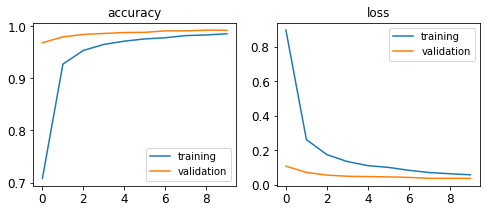

In [218]:
plt.figure(figsize=(8,3))
plt.subplot(121),plt.plot(history.history['accuracy'],label='training');plt.plot(history.history['val_accuracy'],label='validation');plt.title('accuracy')
plt.legend()
plt.subplot(122),plt.plot(history.history['loss'],label='training');plt.plot(history.history['val_loss'],label='validation');plt.title('loss')
plt.legend()

## Compare with 1D network

In [219]:
model1d = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal",activation="relu"),
    keras.layers.Dense(100, kernel_initializer="he_normal",activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])
model1d.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [220]:
model1d.summary()

Model: "sequential_12"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_14 (Dense)             (None, 300)               235500    
_________________________________________________________________
dense_15 (Dense)             (None, 100)               30100     
_________________________________________________________________
dense_16 (Dense)             (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [221]:
print(X_train[:,:,:,0].shape)
print(y_train.shape)

(55000, 28, 28)
(55000,)


In [222]:


history1d=model1d.fit(X_train[:,:,:,0],y_train,epochs=10,validation_data=(X_valid[:,:,:,0],y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 67us/sample - loss: 1.1282 - accuracy: 0.6751 - val_loss: 0.5519 - val_accuracy: 0.8672
Epoch 2/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.5097 - accuracy: 0.8614 - val_loss: 0.3721 - val_accuracy: 0.9078
Epoch 3/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.3884 - accuracy: 0.8911 - val_loss: 0.3066 - val_accuracy: 0.9218
Epoch 4/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.3306 - accuracy: 0.9064 - val_loss: 0.2707 - val_accuracy: 0.9288
Epoch 5/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.2942 - accuracy: 0.9158 - val_loss: 0.2476 - val_accuracy: 0.9340
Epoch 6/10
55000/55000 [==============================] - 3s 58us/sample - loss: 0.2683 - accuracy: 0.9222 - val_loss: 0.2303 - val_accuracy: 0.9412
Epoch 7/10
55000/55000 [==============================] -

In [223]:
model1d.evaluate(X_test[:,:,:,0],y_test)

10000/10000 [==============================] - 0s 48us/sample - loss: 4495.7396 - accuracy: 0.9378


[4495.739649943874, 0.9378]

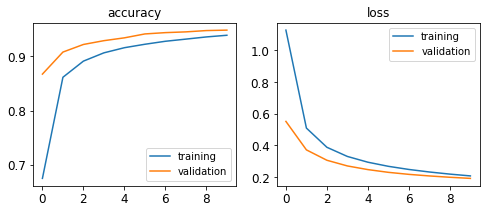

In [224]:
plt.figure(figsize=(8,3))
plt.subplot(121),plt.plot(history1d.history['accuracy'],label='training');plt.plot(history1d.history['val_accuracy'],label='validation');plt.title('accuracy')
plt.legend()
plt.subplot(122),plt.plot(history1d.history['loss'],label='training');plt.plot(history1d.history['val_loss'],label='validation');plt.title('loss')
plt.legend()

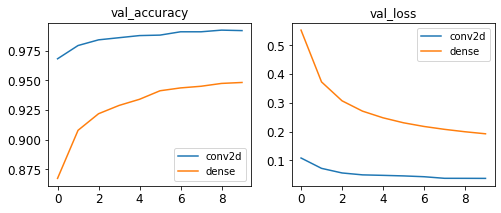

In [225]:
plt.figure(figsize=(8,3))
plt.subplot(121),plt.plot(history.history['val_accuracy'],label='conv2d');plt.plot(history1d.history['val_accuracy'],label='dense');plt.title('val_accuracy')
plt.legend()
plt.subplot(122),plt.plot(history.history['val_loss'],label='conv2d');plt.plot(history1d.history['val_loss'],label='dense');plt.title('val_loss')
plt.legend()

In [226]:
ntest=20;
y_predict2d=model.predict(X_test[:ntest])

In [227]:
y_predict1d=model1d.predict(X_test[:ntest,:,:,0])

In [228]:
print(y_test[:ntest])

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [229]:
print(y_predict2d.shape)

(20, 10)


In [230]:
print(y_predict1d.shape)

(20, 10)


In [231]:
print(['index','true','pred2d','pred1d'])
[print(i,'\t',y_test[i], '\t',y_predict2d[i,:].argmax(), '\t',y_predict1d[i,:].argmax()) for i in range(0,ntest)]

['index', 'true', 'pred2d', 'pred1d']
0 	 7 	 7 	 7
1 	 2 	 2 	 2
2 	 1 	 1 	 1
3 	 0 	 0 	 0
4 	 4 	 4 	 4
5 	 1 	 1 	 1
6 	 4 	 4 	 4
7 	 9 	 9 	 9
8 	 5 	 5 	 4
9 	 9 	 9 	 9
10 	 0 	 0 	 0
11 	 6 	 6 	 6
12 	 9 	 9 	 9
13 	 0 	 0 	 0
14 	 1 	 1 	 1
15 	 5 	 5 	 5
16 	 9 	 9 	 9
17 	 7 	 7 	 7
18 	 3 	 3 	 5
19 	 4 	 4 	 4


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

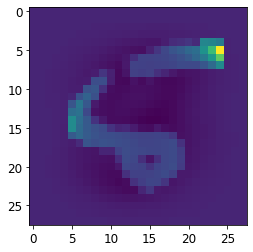

In [233]:
[plt.imshow(X_test[8,:,:,0]) for i in range(0,10)]